# <font color='orange'> Deep Learning </font>
## <font color='lightblue'> Assignment 1 - KHILONA </font>

<font color='sky blue'>=========================================================================================================</font>

In [ ]:
Group_Members = {'Dawood Shahzad' 02-136221-034, 'Bilal Ahmed' 02-136221-028}

<font color='sky blue'>=========================================================================================================</font>

### For this assignment you are required to provide: 
- a) A dataset created by the team members with their own objects (P.S. You cannot use datasets 
provided on the internet and NO PRETRAINED MODELS (e.g. ImageNet)). 
- b) A trained model. (P.S. No ifs and else allowed.) 
- c) Test Accuracy of the trained model.  
- d) The model should correctly predict the conveyor belt for the object provided by the evaluator. 
- e) All the code written should be well explained in your document, with proper screenshots. 
- f) The document should be uploaded on LMS as PDF.

<font color='sky blue'>=========================================================================================================</font>

# 1 - Libraries

In [1]:
import cv2
import os

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import numpy as np
from tensorflow.keras.utils import to_categorical

# 2 - Configurations

In [2]:
# Configurations
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 3  # Blue, Yellow, Purple
CLASS_NAMES = ['blue', 'yellow', 'purple']

dataset_path = "processed_data_own/"

# 3 - Helper Functions [Data Loading, Augmentation]

### 3.1 - Data loading function

In [3]:
# Function to load the dataset and labels
def dataloader(dataset_dir):
    x = []
    y = []
    labels = {}

    # Enumerate through folders to assign labels
    for label_idx, folder in enumerate(sorted(os.listdir(dataset_dir))):
        folder_path = os.path.join(dataset_dir, folder)
        
        if os.path.isdir(folder_path):  # Check if it's a directory
            labels[label_idx] = folder  # Assign label to folder

            # Process images in the folder
            image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg') or f.endswith('.png') or f.endswith('.jpeg')]
            for image_file in image_files:
                image_path = os.path.join(folder_path, image_file)

                image = cv2.resize(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB), IMAGE_SIZE)

                x.append(image)
                y.append(label_idx)

    x = np.array(x)
    y = np.array(y)

    return x, y, labels

### 3.2 - Data augmentation function

In [4]:
# Data Augmentation Function
def augment_data(x, y):
    # Define the ImageDataGenerator for augmentation
    datagen = ImageDataGenerator(
        rotation_range=60,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Augment images
    augmented_x = []
    augmented_y = []

    for i in range(len(x)):
        # Expand dimensions to make it 4D (required by datagen)
        img = np.expand_dims(x[i], axis=0)

        # Augment a single image 50 times
        for _ in range(50):
            aug_iter = datagen.flow(img, batch_size=1)
            aug_img = next(aug_iter)[0]
            augmented_x.append(aug_img)
            augmented_y.append(y[i])

    return np.array(augmented_x), np.array(augmented_y)

# 4 - CNN Architecture

In [5]:
# Defining the CNN Architecture
def CNN():
    model = models.Sequential([
        Input(shape=(IMAGE_SIZE[0],IMAGE_SIZE[1],3)),
        
        # First convolutional block
        layers.Conv2D(16, (3, 3), activation='relu',),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Second convolutional block
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        # Fully connected layer
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.5),  # Dropout for regularization

        # Output layer with softmax for classification (3 classes)
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model

#### The architecture is kept small because our data is not complex, wse dont need to calculate detailed feature maps from it, we just need to identify the color correctly, so a small and simple model would suffice

#### In the trial and test phase, we found out that complex model architectures were not a good choice for this task, as they did unnecessary calculations and generalized themseelves not on the color, but the shape of these objects, which resulted in poor classifications

# 5 - Model Compilation and Preparation

### 5.1 - Compiling the CNN model

In [6]:
model = CNN()
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

### 5.2 - Loading the data and preparaing it for the model

In [7]:
x, y, labels = dataloader(dataset_path)

# we have total 48 images
x = np.reshape(x, (48, IMAGE_SIZE[0], IMAGE_SIZE[0], 3))
y = to_categorical(y, num_classes = 3)

### 5.3 - Performing augmentation to increase the dataset size

In [8]:
# Perform data augmentation
x_augmented, y_augmented = augment_data(x, y)

# Normalize the data
x_augmented = x_augmented / 255.0

# Shuffle the augmented data
indices = np.arange(len(x_augmented))
np.random.shuffle(indices)

# After shuffling, reshape the augmented data into a 4D array:
x_augmented = x_augmented[indices]
x_augmented = np.reshape(x_augmented,(2400,IMAGE_SIZE[0],IMAGE_SIZE[0], 3))
y_augmented = y_augmented[indices]

## Original dataset size: 48 images
## Images for each class: 16

## After Augmentation: 2400 images

### 5.4 - Loading test data to use for validation

In [10]:
test_data = "data_test/"
test_x = []
test_y = []
test_labels = {}

test_x, test_y, test_labels = dataloader(test_data)

test_x = np.reshape(test_x, (27, IMAGE_SIZE[0], IMAGE_SIZE[0], 3))
test_y = to_categorical(test_y, num_classes = 3)

# 6 - Model Training

### 6.1 - Training model

In [11]:
history = model.fit(x_augmented, y_augmented, 
                     epochs = EPOCHS, 
                     validation_data=(test_x, test_y), 
                     batch_size=BATCH_SIZE)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.7704 - loss: 1.2920 - val_accuracy: 0.7407 - val_loss: 7.2410
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.9450 - loss: 0.1761 - val_accuracy: 0.8148 - val_loss: 24.6170
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9529 - loss: 0.1705 - val_accuracy: 0.8889 - val_loss: 5.4265
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.9699 - loss: 0.1107 - val_accuracy: 0.8889 - val_loss: 11.6590
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.9689 - loss: 0.0750 - val_accuracy: 0.8519 - val_loss: 53.2682
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9668 - loss: 0.1897 - val_accuracy: 0.9630 - val_loss: 21.7316
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9764 - loss: 0.1025 - val_accuracy: 0.9630 - val_loss: 55.5601
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.9800 - loss: 0.1207 - val_accuracy: 0.963

### 6.2 - Plotting model metrics

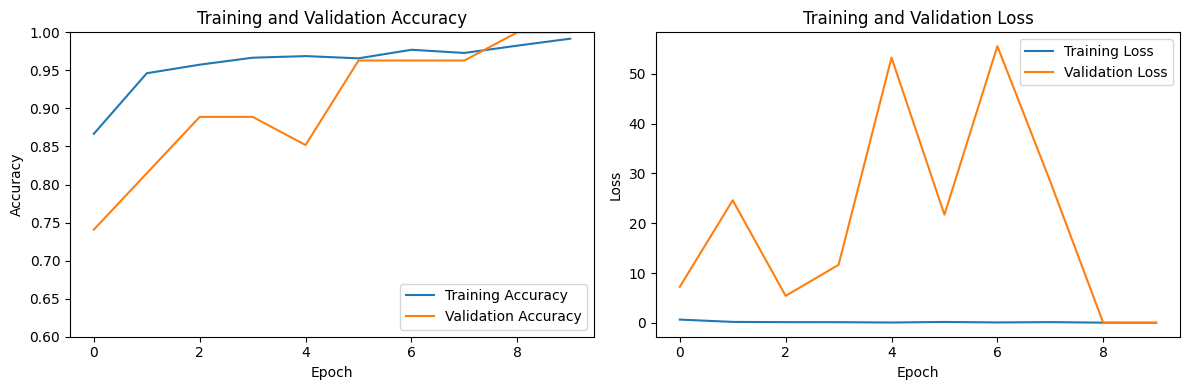

In [16]:
# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0.6, 1])
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    
    plt.tight_layout()
    plt.show()

plot_history(history)

In [17]:
model.save("mydata_128p_2400im_10ep_val.h5")

# 7 - Model Evaluation

### 7.1 - Checking random test image

(27, 128, 128, 3)
{0: 'blue', 1: 'purple', 2: 'yellow'}


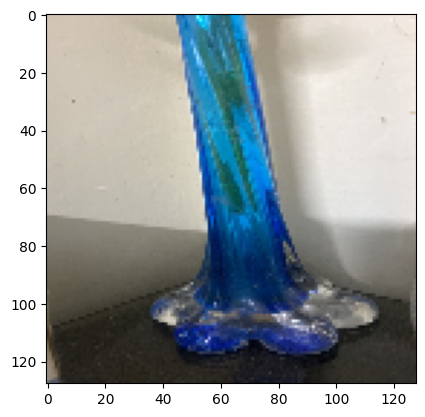

In [19]:
print(test_x.shape)
print(test_labels)
plt.imshow(test_x[8])

In [20]:
t = np.expand_dims(test_x[8], axis=0)
check = model.predict((t / 255.0))
print(check)

# Get the index of the maximum probability for each prediction
max_indices = np.argmax(check, axis=1)
maxx = np.max(check, axis=1)
print(test_labels[int(max_indices[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[[1.0000000e+00 0.0000000e+00 1.7863321e-33]]
blue


### 7.2 - Evaluating the model on test data

In [21]:
model = models.load_model("mydata_128p_2400im_10ep_val.h5")

In [22]:
test_loss, test_acc = model.evaluate(test_x, test_y, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

1/1 - 0s - 271ms/step - accuracy: 1.0000 - loss: 0.0000e+00

Test accuracy: 1.0000


# 8 - User Side

### 8.1 - Function to route objects through colored belts

In [23]:
# Function to classify new objects and route to conveyor belts
def classify_and_route(object_image):

    # Preprocess the image
    img = cv2.resize(object_image, IMAGE_SIZE)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    
    # Make prediction
    predictions = model.predict(img)
    class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    
    # Route to appropriate conveyor belt
    if class_idx == 0:  # Blue
        return 'A', confidence
    elif class_idx == 1:  # Yellow
        return 'B', confidence
    else:  # Purple
        return 'C', confidence

### 8.2 - Sending all test data through the classifier

In [24]:
# Test the classifier with some examples
print("\nTesting classifier with sample objects...")
ttest = zip(test_x, test_y)

print(CLASS_NAMES)

for obj, desc in ttest:
    belt, confidence = classify_and_route(obj)
    print(f"{desc} -> Conveyor Belt {belt} (confidence: {confidence})")


Testing classifier with sample objects...
['blue', 'yellow', 'purple']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[1. 0. 0.] -> Conveyor Belt A (confidence: 1.0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[1. 0. 0.] -> Conveyor Belt A (confidence: 1.0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[1. 0. 0.] -> Conveyor Belt A (confidence: 0.9981348514556885)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[1. 0. 0.] -> Conveyor Belt A (confidence: 1.0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[1. 0. 0.] -> Conveyor Belt A (confidence: 1.0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[1. 0. 0.] -> Conveyor Belt A (confidence: 1.0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[1. 0. 0.] -> Conveyor Belt A (confidence: 1.0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[1. 0. 0.] -> Conveyor Belt A (confidence: 1.0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[1. 0. 0.] -> Conveyor Belt A (confidence: 1.0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[0. 1. 0.] -> Conveyor Belt B (confidence: 1.0)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[0. 1. 0.] -> C

In [ ]:
# for use in manual testing

In [27]:
# Process images in the folder
manual_data = "manual_test/1.png" #put image name here

obj = cv2.cvtColor(cv2.imread(manual_data), cv2.COLOR_BGR2RGB)

belt, confidence = classify_and_route(obj)
print(f" -> Conveyor Belt {belt} (confidence: {confidence})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
 -> Conveyor Belt A (confidence: 1.0)


In [ ]:
A: Blue
B: Yellow
C: Purple